In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = "dataset/mimic-iv-3.1/hosp/"

In [4]:
admissions_df = pd.read_csv(os.path.join(data_path, 'admissions.csv'))
patients_df = pd.read_csv(os.path.join(data_path, 'patients.csv'))
diagnoses_df = pd.read_csv(os.path.join(data_path, 'diagnoses_icd.csv'), low_memory=False)

print("--- admissions.csv loaded ---")
print(f"Shape: {admissions_df.shape}")
print(admissions_df.head())
print("\n")

print("--- patients.csv loaded ---")
print(f"Shape: {patients_df.shape}")
print(patients_df.head())
print("\n")

print("--- diagnoses_icd.csv loaded ---")
print(f"Shape: {diagnoses_df.shape}")
print(diagnoses_df.head())
print("\n")

--- admissions.csv loaded ---
Shape: (546028, 16)
   subject_id   hadm_id            admittime            dischtime deathtime  \
0    10000032  22595853  2180-05-06 22:23:00  2180-05-07 17:15:00       NaN   
1    10000032  22841357  2180-06-26 18:27:00  2180-06-27 18:49:00       NaN   
2    10000032  25742920  2180-08-05 23:44:00  2180-08-07 17:50:00       NaN   
3    10000032  29079034  2180-07-23 12:35:00  2180-07-25 17:55:00       NaN   
4    10000068  25022803  2160-03-03 23:16:00  2160-03-04 06:26:00       NaN   

   admission_type admit_provider_id      admission_location  \
0          URGENT            P49AFC  TRANSFER FROM HOSPITAL   
1        EW EMER.            P784FA          EMERGENCY ROOM   
2        EW EMER.            P19UTS          EMERGENCY ROOM   
3        EW EMER.            P06OTX          EMERGENCY ROOM   
4  EU OBSERVATION            P39NWO          EMERGENCY ROOM   

  discharge_location insurance language marital_status   race  \
0               HOME  Medicaid 

Identify diagnose codes for AMI

In [5]:
d_icd_diagnoses_df = pd.read_csv(os.path.join(data_path, 'd_icd_diagnoses.csv'))
print(f"{d_icd_diagnoses_df.head()}")
print(f"Shape: {d_icd_diagnoses_df.shape}")

  icd_code  icd_version                             long_title
0     0010            9         Cholera due to vibrio cholerae
1     0011            9  Cholera due to vibrio cholerae el tor
2     0019            9                   Cholera, unspecified
3     0020            9                          Typhoid fever
4     0021            9                    Paratyphoid fever A
Shape: (112107, 3)


In [6]:
d_icd_diagnoses_df['long_title'] = d_icd_diagnoses_df['long_title'].astype(str)

In [7]:
ami_codes_df = d_icd_diagnoses_df[
    d_icd_diagnoses_df['long_title'].str.contains("myocardial infarction", case=False, na=False)
].copy()

In [8]:
ami_code_keys = ami_codes_df[['icd_code', 'icd_version', 'long_title']]
diagnoses_df['icd_code'] = diagnoses_df['icd_code'].astype(str)
diagnoses_df['icd_version'] = diagnoses_df['icd_version'].astype(int)

In [9]:
ami_diagnoses = diagnoses_df.merge(ami_code_keys, on=['icd_code', 'icd_version'])

In [10]:
ami_diagnoses.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000764,27897940,12,412,9,Old myocardial infarction
1,10000980,20897796,13,I252,10,Old myocardial infarction
2,10000980,24947999,15,412,9,Old myocardial infarction
3,10000980,25242409,20,412,9,Old myocardial infarction
4,10000980,25911675,11,I252,10,Old myocardial infarction


In [11]:
ami_hadm_ids = ami_diagnoses['hadm_id'].unique()
print(f"Found {len(ami_hadm_ids)} unique hospital admissions with a verified AMI diagnosis.")

Found 40465 unique hospital admissions with a verified AMI diagnosis.


In [12]:
print(f"{ami_hadm_ids}")

[27897940 20897796 24947999 ... 27909016 28129567 28279282]


Filter patient

In [13]:
ami_cohort_df = admissions_df[admissions_df['hadm_id'].isin(ami_hadm_ids)].copy()

In [14]:
ami_cohort_df = ami_cohort_df.merge(patients_df, on='subject_id')
ami_cohort_df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,NaN,URGENT,P38YR6,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicare,...,SINGLE,WHITE,2132-10-14 19:31:00,2132-10-15 16:45:00,0,M,86,2132,2014 - 2016,NaN
1,10000980,20897796,2193-08-15 01:01:00,2193-08-17 15:07:00,NaN,OBSERVATION ADMIT,P55EL5,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,...,MARRIED,BLACK/AFRICAN AMERICAN,2193-08-14 21:25:00,2193-08-15 02:22:00,0,F,73,2186,2008 - 2010,2193-08-26
2,10000980,24947999,2190-11-06 20:57:00,2190-11-08 15:58:00,NaN,EW EMER.,P07L9V,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,...,MARRIED,BLACK/AFRICAN AMERICAN,2190-11-06 15:30:00,2190-11-06 23:16:00,0,F,73,2186,2008 - 2010,2193-08-26
3,10000980,25242409,2191-04-03 18:48:00,2191-04-11 16:21:00,NaN,EW EMER.,P12VNM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,MARRIED,BLACK/AFRICAN AMERICAN,2191-04-03 12:36:00,2191-04-03 20:29:00,0,F,73,2186,2008 - 2010,2193-08-26
4,10000980,25911675,2191-05-23 15:33:00,2191-05-24 17:14:00,NaN,EW EMER.,P87IIY,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,...,MARRIED,BLACK/AFRICAN AMERICAN,2191-05-22 16:06:00,2191-05-23 17:56:00,0,F,73,2186,2008 - 2010,2193-08-26


In [15]:
ami_cohort_df['admittime'] = pd.to_datetime(ami_cohort_df['admittime'])
ami_cohort_df['admission_age'] = ami_cohort_df['anchor_age'] + (ami_cohort_df['admittime'].dt.year - ami_cohort_df['anchor_year'])
ami_cohort_df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,admission_age
0,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,NaN,URGENT,P38YR6,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicare,...,WHITE,2132-10-14 19:31:00,2132-10-15 16:45:00,0,M,86,2132,2014 - 2016,NaN,86
1,10000980,20897796,2193-08-15 01:01:00,2193-08-17 15:07:00,NaN,OBSERVATION ADMIT,P55EL5,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicare,...,BLACK/AFRICAN AMERICAN,2193-08-14 21:25:00,2193-08-15 02:22:00,0,F,73,2186,2008 - 2010,2193-08-26,80
2,10000980,24947999,2190-11-06 20:57:00,2190-11-08 15:58:00,NaN,EW EMER.,P07L9V,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,...,BLACK/AFRICAN AMERICAN,2190-11-06 15:30:00,2190-11-06 23:16:00,0,F,73,2186,2008 - 2010,2193-08-26,77
3,10000980,25242409,2191-04-03 18:48:00,2191-04-11 16:21:00,NaN,EW EMER.,P12VNM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,BLACK/AFRICAN AMERICAN,2191-04-03 12:36:00,2191-04-03 20:29:00,0,F,73,2186,2008 - 2010,2193-08-26,78
4,10000980,25911675,2191-05-23 15:33:00,2191-05-24 17:14:00,NaN,EW EMER.,P87IIY,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,...,BLACK/AFRICAN AMERICAN,2191-05-22 16:06:00,2191-05-23 17:56:00,0,F,73,2186,2008 - 2010,2193-08-26,78


Filter out patient who are 18+

In [16]:
initial_count = len(ami_cohort_df)
ami_cohort_df = ami_cohort_df[ami_cohort_df['admission_age'] >= 18]
adult_count = len(ami_cohort_df)
print(f"Filtered out {initial_count - adult_count} non-adult admissions.")
print(f"Final adult AMI cohort size: {adult_count} admissions.")

Filtered out 0 non-adult admissions.
Final adult AMI cohort size: 40465 admissions.


In [17]:
print("\n--- Final AMI Cohort DataFrame ---")
print(ami_cohort_df.head())

print("\n--- Cohort Mortality Outcome ---")
print(ami_cohort_df['hospital_expire_flag'].value_counts(normalize=True))


--- Final AMI Cohort DataFrame ---
   subject_id   hadm_id           admittime            dischtime deathtime  \
0    10000764  27897940 2132-10-14 23:31:00  2132-10-19 16:30:00       NaN   
1    10000980  20897796 2193-08-15 01:01:00  2193-08-17 15:07:00       NaN   
2    10000980  24947999 2190-11-06 20:57:00  2190-11-08 15:58:00       NaN   
3    10000980  25242409 2191-04-03 18:48:00  2191-04-11 16:21:00       NaN   
4    10000980  25911675 2191-05-23 15:33:00  2191-05-24 17:14:00       NaN   

      admission_type admit_provider_id      admission_location  \
0             URGENT            P38YR6  TRANSFER FROM HOSPITAL   
1  OBSERVATION ADMIT            P55EL5   WALK-IN/SELF REFERRAL   
2           EW EMER.            P07L9V          EMERGENCY ROOM   
3           EW EMER.            P12VNM          EMERGENCY ROOM   
4           EW EMER.            P87IIY          EMERGENCY ROOM   

         discharge_location insurance  ...                    race  \
0          HOME HEALTH CARE 

# Analyze

Cohort Mortality Outcome

In [18]:
mortality_counts = ami_cohort_df['hospital_expire_flag'].value_counts()
mortality_percent = ami_cohort_df['hospital_expire_flag'].value_counts(
    normalize=True) * 100

print(f"Counts:\n{mortality_counts}")
print(f"\nPercentages:\n{mortality_percent}")
print("\n")

Counts:
hospital_expire_flag
0    38439
1     2026
Name: count, dtype: int64

Percentages:
hospital_expire_flag
0    94.993204
1     5.006796
Name: proportion, dtype: float64




Age Statistics by Outcome

In [19]:
age_stats = ami_cohort_df.groupby('hospital_expire_flag')[
    'admission_age'].describe()
print(age_stats)
print("\n")

                        count       mean        std   min   25%   50%   75%  \
hospital_expire_flag                                                          
0                     38439.0  70.634408  13.065564  19.0  62.0  71.0  80.0   
1                      2026.0  75.366732  12.390927  23.0  68.0  77.0  85.0   

                        max  
hospital_expire_flag         
0                     103.0  
1                     100.0  




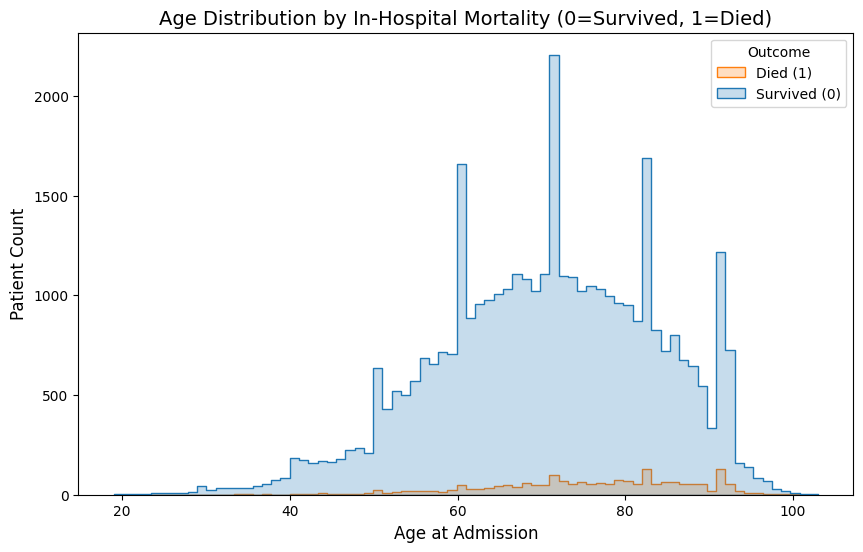

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=ami_cohort_df,
             x='admission_age',
             hue='hospital_expire_flag',  
            #  kde=True,             
             element="step")       
plt.title(
    'Age Distribution by In-Hospital Mortality (0=Survived, 1=Died)', fontsize=14)
plt.xlabel('Age at Admission', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.legend(title='Outcome', labels=['Died (1)', 'Survived (0)'])
plt.show()

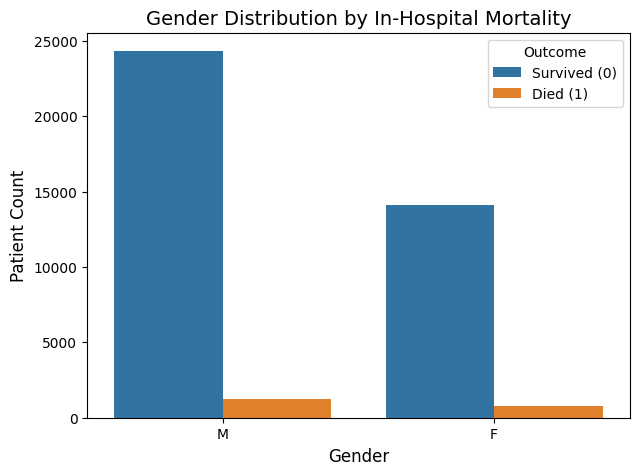

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(data=ami_cohort_df,
              x='gender',
              hue='hospital_expire_flag')
plt.title('Gender Distribution by In-Hospital Mortality', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.legend(title='Outcome', labels=['Survived (0)', 'Died (1)'])
plt.show()

# Lab event Data

In [ ]:
d_labitems_df = pd.read_csv(os.path.join(data_path, 'd_labitems.csv'))

d_labitems_df.head()

,itemid,label,fluid,category
0,50801,Alveolar-arterial Gradient,Blood,Blood Gas
1,50802,Base Excess,Blood,Blood Gas
2,50803,"Calculated Bicarbonate, Whole Blood",Blood,Blood Gas
3,50804,Calculated Total CO2,Blood,Blood Gas
4,50805,Carboxyhemoglobin,Blood,Blood Gas


In [27]:
bnp_labels = d_labitems_df[d_labitems_df['label'].str.contains("BNP", case=False, na=False)]['label'].unique()
print("Found the following labels containing 'BNP':")
print(bnp_labels)

Found the following labels containing 'BNP':
['NTproBNP' 'proBNP, Pleural']


In [28]:
troponin_id = d_labitems_df[d_labitems_df['label'] == 'Troponin T']['itemid'].values[0]
ck_mb_id = d_labitems_df[d_labitems_df['label'] == 'Creatine Kinase, MB Isoenzyme']['itemid'].values[0]
bnp_id = d_labitems_df[d_labitems_df['label'] == 'NTproBNP']['itemid'].values[0]

key_lab_itemids = [troponin_id, ck_mb_id, bnp_id]

print(f"  Troponin T: {troponin_id}")
print(f"  CK-MB: {ck_mb_id}")
print(f"  BNP (NT-proBNP): {bnp_id}")

  Troponin T: 51003
  CK-MB: 50911
  BNP (NT-proBNP): 50963


In [31]:
cohort_hadm_ids_set = set(ami_cohort_df['hadm_id'])
key_lab_itemids_set = set(key_lab_itemids)
labevents_file_path = os.path.join(data_path, 'labevents.csv')
chunk_size = 1_000_000
filtered_chunks = []

In [32]:
try:
    chunk_iterator = pd.read_csv(labevents_file_path,
                                 chunksize=chunk_size,
                                 # Only load columns we actually need
                                 usecols=['hadm_id', 'itemid', 'charttime', 'valuenum', 'valueuom'])

    
    for i, chunk in enumerate(chunk_iterator):
        print(f"  Processing chunk {i+1}...")

        filtered_chunk = chunk[chunk['hadm_id'].isin(cohort_hadm_ids_set)]

        filtered_chunk = filtered_chunk[filtered_chunk['itemid'].isin(
            key_lab_itemids_set)]

        if not filtered_chunk.empty:
            filtered_chunks.append(filtered_chunk)
            print(
                f"    Found {len(filtered_chunk)} relevant lab events in this chunk.")

    print("\nFile processing complete.")

    if filtered_chunks:
        ami_labs_df = pd.concat(filtered_chunks)
        print(
            f"\nSuccessfully created final ami_labs_df with {len(ami_labs_df)} rows.")
        print(ami_labs_df.head())
    else:
        print("\nNo lab events found for the specified cohort and item IDs.")

except FileNotFoundError:
    print(f"ERROR: Could not find 'labevents.csv.gz' at {labevents_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

  Processing chunk 1...
    Found 781 relevant lab events in this chunk.
  Processing chunk 2...
    Found 751 relevant lab events in this chunk.
  Processing chunk 3...
    Found 673 relevant lab events in this chunk.
  Processing chunk 4...
    Found 936 relevant lab events in this chunk.
  Processing chunk 5...
    Found 739 relevant lab events in this chunk.
  Processing chunk 6...
    Found 802 relevant lab events in this chunk.
  Processing chunk 7...
    Found 865 relevant lab events in this chunk.
  Processing chunk 8...
    Found 676 relevant lab events in this chunk.
  Processing chunk 9...
    Found 644 relevant lab events in this chunk.
  Processing chunk 10...
    Found 750 relevant lab events in this chunk.
  Processing chunk 11...
    Found 714 relevant lab events in this chunk.
  Processing chunk 12...
    Found 700 relevant lab events in this chunk.
  Processing chunk 13...
    Found 649 relevant lab events in this chunk.
  Processing chunk 14...
    Found 736 relevant

# Lab Feature enginnering

In [33]:
ami_labs_df = ami_labs_df.dropna(subset=['hadm_id', 'valuenum', 'charttime'])
ami_labs_df['hadm_id'] = ami_labs_df['hadm_id'].astype(int)
ami_labs_df['charttime'] = pd.to_datetime(ami_labs_df['charttime'])

In [34]:
admission_times = ami_cohort_df[['hadm_id', 'admittime']].copy()
admission_times['admittime'] = pd.to_datetime(admission_times['admittime'])

In [35]:
labs_with_admittime = ami_labs_df.merge(admission_times, on='hadm_id')
labs_with_admittime['hours_from_admission'] = (labs_with_admittime['charttime'] - labs_with_admittime['admittime']).dt.total_seconds() / 3600

In [36]:
labs_with_admittime.head()

,hadm_id,itemid,charttime,valuenum,valueuom,admittime,hours_from_admission
0,27897940,51003,2132-10-15 07:45:00,0.04,ng/mL,2132-10-14 23:31:00,8.233333
1,27897940,50911,2132-10-16 06:03:00,36.00,ng/mL,2132-10-14 23:31:00,30.533333
2,27897940,51003,2132-10-16 06:03:00,0.57,ng/mL,2132-10-14 23:31:00,30.533333
3,27897940,50911,2132-10-16 15:03:00,23.00,ng/mL,2132-10-14 23:31:00,39.533333
4,27897940,51003,2132-10-16 15:03:00,0.89,ng/mL,2132-10-14 23:31:00,39.533333


In [37]:
first_24h_labs = labs_with_admittime[
    (labs_with_admittime['hours_from_admission'] >= 0) &
    (labs_with_admittime['hours_from_admission'] <= 24)
].copy()
print(f"Found {len(first_24h_labs)} lab events within the first 24 hours.")

Found 50688 lab events within the first 24 hours.


In [ ]:
peak_labs = first_24h_labs.groupby(['hadm_id', 'itemid'])['valuenum'].max().reset_index()

Calculated peak lab values for each admission.


In [39]:
peak_labs_pivot = peak_labs.pivot_table(index='hadm_id',columns='itemid', values='valuenum').reset_index()

In [40]:
peak_labs_pivot = peak_labs_pivot.rename(columns={
    troponin_id: 'Troponin_T_max',
    ck_mb_id: 'CK_MB_max',
    bnp_id: 'BNP_max'
})

In [41]:
ami_cohort_df = ami_cohort_df.merge(peak_labs_pivot, on='hadm_id', how='left')

print("\n--- Successfully merged lab features into main cohort ---")
print(f"Cohort DataFrame shape is now: {ami_cohort_df.shape}")
print("New columns have been added (see end of list):")
print(ami_cohort_df.info())

print("\n--- Example of new lab features (may contain NaNs) ---")
print(ami_cohort_df[['hadm_id', 'Troponin_T_max',
      'CK_MB_max', 'BNP_max']].head())


--- Successfully merged lab features into main cohort ---
Cohort DataFrame shape is now: (40465, 25)
New columns have been added (see end of list):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40465 entries, 0 to 40464
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            40465 non-null  int64         
 1   hadm_id               40465 non-null  int64         
 2   admittime             40465 non-null  datetime64[ns]
 3   dischtime             40465 non-null  object        
 4   deathtime             2023 non-null   object        
 5   admission_type        40465 non-null  object        
 6   admit_provider_id     40465 non-null  object        
 7   admission_location    40465 non-null  object        
 8   discharge_location    34409 non-null  object        
 9   insurance             40204 non-null  object        
 10  language              40371 non-null  obj

In [42]:
print("--- Analyzing Missingness vs. Mortality ---")

# Create a copy to avoid changing the original dataframe
analysis_df = ami_cohort_df.copy()

# 1. Create "missingness" flags
analysis_df['Troponin_T_missing'] = analysis_df['Troponin_T_max'].isnull().astype(int)
analysis_df['CK_MB_missing'] = analysis_df['CK_MB_max'].isnull().astype(int)
analysis_df['BNP_missing'] = analysis_df['BNP_max'].isnull().astype(int)

# 2. Analyze Troponin missingness
print("\n--- Troponin T ---")
# Group by the missingness flag and get the mean of the mortality flag
print(analysis_df.groupby('Troponin_T_missing')['hospital_expire_flag'].mean())

# 3. Analyze CK_MB missingness
print("\n--- CK-MB ---")
print(analysis_df.groupby('CK_MB_missing')['hospital_expire_flag'].mean())

# 4. Analyze BNP missingness
print("\n--- BNP ---")
print(analysis_df.groupby('BNP_missing')['hospital_expire_flag'].mean())

--- Analyzing Missingness vs. Mortality ---

--- Troponin T ---
Troponin_T_missing
0    0.091774
1    0.030956
Name: hospital_expire_flag, dtype: float64

--- CK-MB ---
CK_MB_missing
0    0.079853
1    0.034461
Name: hospital_expire_flag, dtype: float64

--- BNP ---
BNP_missing
0    0.096529
1    0.047850
Name: hospital_expire_flag, dtype: float64


In [45]:
# --- Fix for Parquet: Convert all 'object' columns to 'string' ---
print("Converting object columns to string data type for Parquet compatibility...")

# Find all columns that are 'object' type
object_cols = ami_cohort_df.select_dtypes(include=['object']).columns

# Loop through and convert them
for col in object_cols:
    ami_cohort_df[col] = ami_cohort_df[col].astype('string')

print("Conversion complete.")
print(ami_cohort_df.info())

Converting object columns to string data type for Parquet compatibility...
Conversion complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40465 entries, 0 to 40464
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            40465 non-null  int64         
 1   hadm_id               40465 non-null  int64         
 2   admittime             40465 non-null  datetime64[ns]
 3   dischtime             40465 non-null  string        
 4   deathtime             2023 non-null   string        
 5   admission_type        40465 non-null  string        
 6   admit_provider_id     40465 non-null  string        
 7   admission_location    40465 non-null  string        
 8   discharge_location    34409 non-null  string        
 9   insurance             40204 non-null  string        
 10  language              40371 non-null  string        
 11  marital_status        38851 non-null

In [46]:
filtered_data_path = "dataset/filteredData/"

# Ensure the directory exists before saving
os.makedirs(filtered_data_path, exist_ok=True) 

print("Attempting to save as Parquet...")

try:
    # --- Try to save as Parquet (preferred) ---
    parquet_path = os.path.join(filtered_data_path, 'ami_cohort_structured_features.parquet')
    ami_cohort_df.to_parquet(parquet_path, index=False)
    print(f"\nSuccessfully saved final cohort to: {parquet_path}")

except Exception as e:
    # --- Fallback to CSV if Parquet fails for ANY reason ---
    print(f"\nParquet save failed with error: {e}")
    print("Falling back to saving as CSV...")
    
    try:
        csv_path = os.path.join(filtered_data_path, 'ami_cohort_structured_features.csv')
        ami_cohort_df.to_csv(csv_path, index=False)
        print(f"Successfully saved final cohort to: {csv_path}")
    except Exception as csv_e:
        print(f"--- CRITICAL ERROR ---")
        print(f"Even saving as CSV failed: {csv_e}")
        print("Please check your file path and permissions.")

Attempting to save as Parquet...

Parquet save failed with error: A type extension with name pandas.period already defined
Falling back to saving as CSV...
--- CRITICAL ERROR ---
Even saving as CSV failed: [Errno 13] Permission denied: 'dataset/filteredData/ami_cohort_structured_features.csv'
Please check your file path and permissions.


An error occurred while saving: No type extension with name arrow.py_extension_type found
